# 17. Monitoring Drift, Degradation, and Feedback Loops

A model does not stop being a model once it is deployed. After deployment, the environment changes, operational policies change, and the model itself may start influencing the labels that future monitoring and retraining use. This notebook studies that full lifecycle problem in a single operational setting.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Distinguish covariate drift, concept drift, and policy-induced feedback loops.
2. Explain why feature drift alerts and performance alerts answer different questions.
3. Compute simple production-style monitoring statistics such as PSI, calibration gaps, and threshold-based queue metrics.
4. Interpret when a change in observed outcomes signals model degradation versus intervention success.
5. Design a monitoring workflow that supports defensible retraining decisions rather than reflexive retraining.

## 1. Core Mathematical Ideas

Suppose a fixed scoring model produces a risk score

$$
S_t = f(X_t)
$$

for observations arriving at time $t$.

Three deployment failures that look similar on a dashboard are actually different.

**Covariate drift** means the feature distribution changes:

$$
P_t(X) \neq P_{\mathrm{ref}}(X).
$$

**Concept drift** means the outcome mechanism changes:

$$
P_t(Y \mid X) \neq P_{\mathrm{ref}}(Y \mid X).
$$

**Score drift** means the model's own score distribution changes:

$$
P_t(S) \neq P_{\mathrm{ref}}(S).
$$

A simple monitoring statistic for distribution change is the **population stability index** (PSI). If $p_i$ is the reference share in bin $i$ and $q_i$ is the current share, then

$$
\mathrm{PSI} = \sum_{i=1}^B (q_i - p_i) \log\left(\frac{q_i}{p_i}\right).
$$

PSI is useful because it turns "these histograms look different" into a scalar diagnostic. But PSI alone cannot tell us whether model quality has actually deteriorated.

For outcome-based monitoring, a useful calibration summary is the gap between realized event rate and average predicted risk:

$$
\mathrm{Gap}_t = \mathbb{E}[Y_t] - \mathbb{E}[S_t].
$$

A final complication appears when deployment actions change outcomes. If a score-based policy applies an intervention $A_t \in \{0,1\}$, then the observed outcome is

$$
Y_t^{\mathrm{obs}} = A_t Y_t(1) + (1-A_t)Y_t(0).
$$

This means that after deployment, the labels used for monitoring and retraining may reflect both the model **and** the policy triggered by the model. In other words, the production system can start training on its own footprint.

In [1]:
# Section focus: 1. Core Mathematical Ideas.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)


def logistic(x):
    """Carry out the logistic step used in the 17. Monitoring Drift, Degradation, and Feedback Loops workflow.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Intermediate result produced by the logistic calculation and reused by later cells.
    """
    return 1 / (1 + np.exp(-x))


def safe_auc(y_true, score):
    """Carry out the safe auc step used in the 17. Monitoring Drift, Degradation, and Feedback Loops workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the safe auc calculation.
    """
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, score)


def safe_ap(y_true, score):
    """Carry out the safe ap step used in the 17. Monitoring Drift, Degradation, and Feedback Loops workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the safe ap calculation.
    """
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return average_precision_score(y_true, score)


def safe_brier(y_true, score):
    """Carry out the safe brier step used in the 17. Monitoring Drift, Degradation, and Feedback Loops workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    
    Returns
    -------
    object
        Intermediate result produced by the safe brier calculation and reused by later cells.
    """
    if len(y_true) == 0:
        return np.nan
    return brier_score_loss(y_true, score)


def population_stability_index(reference, current, bins=10):
    """Carry out the population stability index step used in the 17. Monitoring Drift, Degradation, and Feedback Loops workflow.
    
    Parameters
    ----------
    reference : object
        The reference setting that controls the population stability index calculation in this notebook.
    current : object
        The current setting that controls the population stability index calculation in this notebook.
    bins : object
        The bins setting that controls the population stability index calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the population stability index calculation and reused by later cells.
    """
    reference = np.asarray(reference)
    current = np.asarray(current)

    edges = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    if len(edges) < 4:
        lo = min(reference.min(), current.min())
        hi = max(reference.max(), current.max()) + 1e-9
        edges = np.linspace(lo, hi, bins + 1)

    edges = edges.astype(float)
    edges[0] = -np.inf
    edges[-1] = np.inf

    ref_counts, _ = np.histogram(reference, bins=edges)
    cur_counts, _ = np.histogram(current, bins=edges)

    ref_prop = np.clip(ref_counts / max(ref_counts.sum(), 1), 1e-6, None)
    cur_prop = np.clip(cur_counts / max(cur_counts.sum(), 1), 1e-6, None)

    return float(np.sum((cur_prop - ref_prop) * np.log(cur_prop / ref_prop)))

phase_order = ["Stable train", "Stable deploy", "Covariate drift", "Concept drift", "Feedback loop"]
phase_colors = {
    "Stable train": "#d9d9d9",
    "Stable deploy": "#c6dbef",
    "Covariate drift": "#9ecae1",
    "Concept drift": "#fdae6b",
    "Feedback loop": "#fdd0a2",
}


## 2. Operational Setting and Deployment Phases

We will continue with a seller-support risk model. The target is whether a seller-day ends in an SLA breach.

The environment evolves through five phases:

1. **Stable train**: the model is trained on a stationary historical regime.
2. **Stable deploy**: the model is deployed into a similar environment.
3. **Covariate drift**: the workload profile shifts upward, so visible features move.
4. **Concept drift**: a hidden vendor outage process appears, changing breach risk in a way the feature set does not directly encode.
5. **Feedback loop**: the model's own triage queue triggers interventions that prevent some breaches, so observed labels begin to reflect policy as well as risk.

This design lets us separate three questions that often get blurred together in practice:

- Did the input distribution move?
- Did the predictive relationship move?
- Did our own actions change the labels we are now using to judge the model?

In [2]:
# Section focus: 2. Operational Setting and Deployment Phases.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def simulate_support_environment(n_sellers=180, n_days=220, random_state=2026):
    """Create a simulated support environment data set for the 17. Monitoring Drift, Degradation, and Feedback Loops case study.
    
    Parameters
    ----------
    n_sellers : object
        Count or size setting for the support environment calculation.
    n_days : object
        Count or size setting for the support environment calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)

    seller_ids = np.arange(n_sellers)
    tiers = rng.choice(["SMB", "Mid-Market", "Enterprise"], size=n_sellers, p=[0.5, 0.32, 0.18])
    regions = rng.choice(["North America", "Europe", "APAC"], size=n_sellers, p=[0.46, 0.29, 0.25])
    channels = rng.choice(["Email", "Chat", "Phone"], size=n_sellers, p=[0.45, 0.35, 0.20])
    analyst_experience = np.clip(rng.normal(4.8, 1.6, size=n_sellers), 0.5, 10.0)
    base_risk = rng.normal(0.0, 1.0, size=n_sellers)
    migration_prone = rng.binomial(1, 0.28, size=n_sellers)

    pressure_state = rng.normal(0.0, 0.55, size=n_sellers)
    backlog_state = np.clip(rng.normal(4.5, 1.2, size=n_sellers), 1.0, 9.0)

    def phase_name(day_idx):
        """Carry out the phase name step used in the 17. Monitoring Drift, Degradation, and Feedback Loops workflow.
        
        Parameters
        ----------
        day_idx : object
            Integer day index used to locate a simulated event or observation.
        
        Returns
        -------
        object
            Intermediate result produced by the phase name calculation and reused by later cells.
        """
        if day_idx < 110:
            return "Stable train"
        if day_idx < 140:
            return "Stable deploy"
        if day_idx < 170:
            return "Covariate drift"
        if day_idx < 195:
            return "Concept drift"
        return "Feedback loop"

    dates = pd.date_range("2025-01-01", periods=n_days, freq="D")
    records = []

    for day_idx, date in enumerate(dates):
        phase = phase_name(day_idx)
        weekend = int(date.weekday() >= 5)
        release_window = int(day_idx % 28 in [5, 6, 7])

        phase_pressure_shift = {
            "Stable train": 0.00,
            "Stable deploy": 0.00,
            "Covariate drift": 0.18,
            "Concept drift": 0.18,
            "Feedback loop": 0.18,
        }[phase]

        outage_probability = {
            "Stable train": 0.00,
            "Stable deploy": 0.00,
            "Covariate drift": 0.00,
            "Concept drift": 0.12,
            "Feedback loop": 0.12,
        }[phase]

        for seller_idx, seller_id in enumerate(seller_ids):
            tier = tiers[seller_idx]
            region = regions[seller_idx]
            channel = channels[seller_idx]
            experience = analyst_experience[seller_idx]
            seller_risk = base_risk[seller_idx]
            prior_pressure = pressure_state[seller_idx]
            prior_backlog = backlog_state[seller_idx]

            enterprise = int(tier == "Enterprise")
            apac = int(region == "APAC")
            email = int(channel == "Email")

            current_pressure = (
                0.92 * prior_pressure
                + rng.normal(0.0, 0.18)
                + 0.14 * weekend
                + 0.16 * release_window
                + 0.08 * seller_risk
                + phase_pressure_shift
            )

            workflow_migration_today = rng.binomial(
                1,
                min(
                    0.01
                    + 0.05 * migration_prone[seller_idx]
                    + 0.03 * enterprise
                    + 0.02 * apac
                    + 0.05 * release_window,
                    0.35,
                ),
            )
            vendor_outage_today = rng.binomial(1, outage_probability)

            tickets_mean = np.exp(
                0.85
                + 0.18 * seller_risk
                + 0.22 * current_pressure
                + 0.06 * prior_backlog
                + 0.06 * email
                + 0.22 * workflow_migration_today
            )
            tickets_opened = rng.poisson(min(tickets_mean, 18))

            queue_load = max(
                0.5,
                3.0
                + 0.9 * tickets_opened
                + 1.0 * max(current_pressure, 0)
                + 0.30 * prior_backlog
                + rng.normal(0.0, 0.7),
            )

            backlog_end = max(
                0.0,
                0.70 * prior_backlog
                + 0.22 * tickets_opened
                - (3.8 + 0.35 * experience + rng.normal(0.0, 0.6)),
            )

            resolution_minutes = max(
                12.0,
                42
                + 1.8 * tickets_opened
                + 4.5 * max(current_pressure, 0)
                + 1.4 * prior_backlog
                + 4.0 * enterprise
                + 2.5 * apac
                + 3.0 * seller_risk
                - 1.4 * experience
                + 8.0 * workflow_migration_today
                + 10.0 * vendor_outage_today
                + rng.normal(0.0, 4.0),
            )

            natural_logit = (
                -2.85
                + 0.45 * seller_risk
                + 0.60 * current_pressure
                + 0.04 * tickets_opened
                + 0.08 * prior_backlog
                + 0.006 * resolution_minutes
                + 0.55 * workflow_migration_today
                + 0.80 * vendor_outage_today
                + 0.08 * release_window
                + 0.08 * apac
                - 0.08 * experience
            )
            natural_prob = logistic(natural_logit)
            natural_breach = rng.binomial(1, natural_prob)

            records.append(
                {
                    "seller_id": seller_id,
                    "date": date,
                    "phase": phase,
                    "tier": tier,
                    "region": region,
                    "channel": channel,
                    "analyst_experience": experience,
                    "tickets_opened": tickets_opened,
                    "queue_load": queue_load,
                    "backlog_end": backlog_end,
                    "resolution_minutes": resolution_minutes,
                    "workflow_migration_today": workflow_migration_today,
                    "vendor_outage_today": vendor_outage_today,
                    "weekday": date.weekday(),
                    "release_window": release_window,
                    "natural_logit": natural_logit,
                    "natural_prob": natural_prob,
                    "natural_breach": natural_breach,
                }
            )

            pressure_state[seller_idx] = 0.90 * current_pressure + 0.12 * natural_breach + 0.02 * (queue_load / 10)
            backlog_state[seller_idx] = np.clip(backlog_end, 0.0, 16.0)

    return pd.DataFrame(records)


def build_feature_matrix(df):
    """Build the feature matrix object used in the 17. Monitoring Drift, Degradation, and Feedback Loops analysis.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the feature matrix workflow for later analysis.
    """
    feature_df = df.sort_values(["seller_id", "date"]).copy()
    grouped = feature_df.groupby("seller_id", group_keys=False)

    feature_df["prior_backlog"] = grouped["backlog_end"].shift(1)
    feature_df["prior_queue_load"] = grouped["queue_load"].shift(1)
    feature_df["prior_tickets"] = grouped["tickets_opened"].shift(1)

    feature_df["backlog_7d_mean"] = grouped["backlog_end"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)
    feature_df["queue_7d_mean"] = grouped["queue_load"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)
    feature_df["tickets_7d_mean"] = grouped["tickets_opened"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)
    feature_df["breach_rate_7d"] = grouped["natural_breach"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)
    feature_df["resolution_7d_mean"] = grouped["resolution_minutes"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)

    feature_df["recent_backlog_jump"] = feature_df["prior_backlog"] - feature_df["backlog_7d_mean"]
    feature_df["queue_pressure_gap"] = feature_df["prior_queue_load"] - feature_df["queue_7d_mean"]

    feature_df["weekday_sin"] = np.sin(2 * np.pi * feature_df["weekday"] / 7)
    feature_df["weekday_cos"] = np.cos(2 * np.pi * feature_df["weekday"] / 7)

    return feature_df.dropna().reset_index(drop=True)


ops = simulate_support_environment()
feature_df = build_feature_matrix(ops)
feature_df.head()

,seller_id,date,phase,tier,region,channel,analyst_experience,tickets_opened,queue_load,backlog_end,resolution_minutes,workflow_migration_today,vendor_outage_today,weekday,release_window,natural_logit,natural_prob,natural_breach,prior_backlog,prior_queue_load,prior_tickets,backlog_7d_mean,queue_7d_mean,tickets_7d_mean,breach_rate_7d,resolution_7d_mean,recent_backlog_jump,queue_pressure_gap,weekday_sin,weekday_cos
0,0,2025-01-02,Stable train,SMB,Europe,Chat,4.4241,2,4.509543,0.0,46.130936,0,0,3,0,-2.363212,0.086021,0,0.0,6.990560,3.0,0.0,8.853678,3.857143,0.714286,60.709750,0.0,-1.863118,0.433884,-0.900969
1,0,2025-01-03,Stable train,SMB,Europe,Chat,4.4241,3,6.845766,0.0,42.494447,0,0,4,0,-2.181918,0.101386,0,0.0,4.509543,2.0,0.0,3.901641,0.857143,0.000000,26.272817,0.0,0.607902,-0.433884,-0.900969
2,0,2025-01-04,Stable train,SMB,Europe,Chat,4.4241,1,5.550099,0.0,45.093822,0,0,5,0,-2.066114,0.112434,0,0.0,6.845766,3.0,0.0,4.764965,2.000000,0.000000,43.652002,0.0,2.080801,-0.974928,-0.222521
3,0,2025-01-05,Stable train,SMB,Europe,Chat,4.4241,3,5.801678,0.0,41.223765,0,0,6,0,-1.924900,0.127316,1,0.0,5.550099,1.0,0.0,4.995862,2.142857,0.000000,37.753348,0.0,0.554238,-0.781831,0.623490
4,0,2025-01-06,Stable train,SMB,Europe,Chat,4.4241,1,5.146161,0.0,43.663696,0,0,0,1,-1.887228,0.131561,1,0.0,5.801678,3.0,0.0,7.748149,4.285714,0.142857,48.698818,0.0,-1.946471,0.000000,1.000000


The Operational Setting and Deployment Phases result matters when it changes the next move. This output matters when it changes how the system would be used.


,phase,rows,sellers,avg_prior_queue,outage_share,natural_breach_rate
0,Stable train,19620,180,6.116597,0.000000,0.098012
1,Stable deploy,5400,180,6.078547,0.000000,0.094630
2,Covariate drift,5400,180,7.457220,0.000000,0.158519
3,Concept drift,4500,180,7.861974,0.122000,0.194222
4,Feedback loop,4500,180,7.881330,0.120444,0.199778


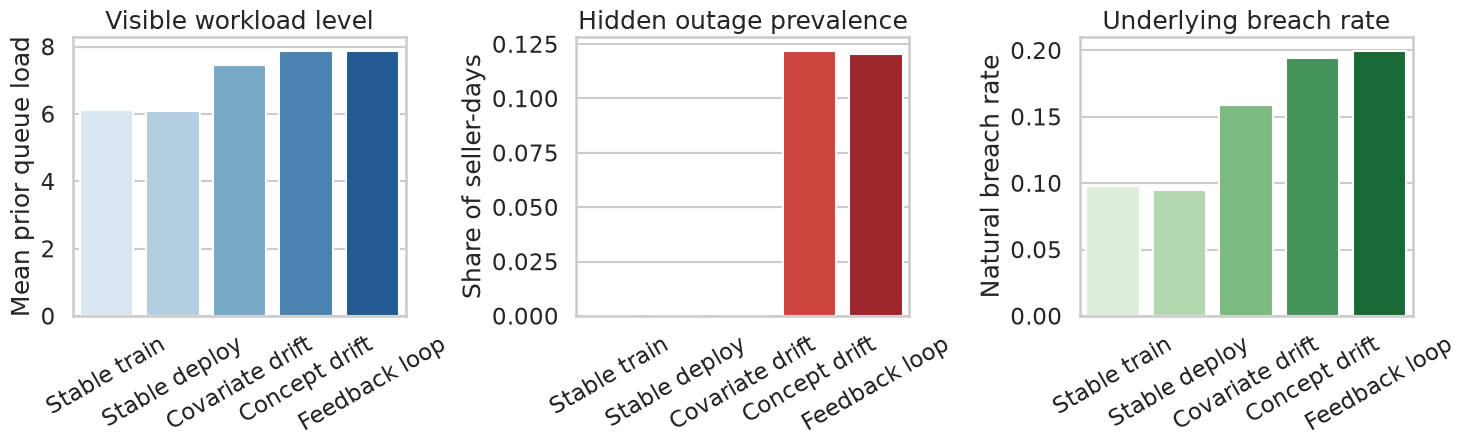

In [3]:
# Section focus: 2. Operational Setting and Deployment Phases.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

phase_overview = (
    feature_df.groupby("phase")
    .agg(
        rows=("seller_id", "size"),
        sellers=("seller_id", "nunique"),
        avg_prior_queue=("prior_queue_load", "mean"),
        outage_share=("vendor_outage_today", "mean"),
        natural_breach_rate=("natural_breach", "mean"),
    )
    .reindex(phase_order)
    .reset_index()
)

display(phase_overview)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

sns.barplot(data=phase_overview, x="phase", y="avg_prior_queue", palette="Blues", order=phase_order, ax=axes[0])
axes[0].set_title("Visible workload level")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean prior queue load")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=phase_overview, x="phase", y="outage_share", palette="Reds", order=phase_order, ax=axes[1])
axes[1].set_title("Hidden outage prevalence")
axes[1].set_xlabel("")
axes[1].set_ylabel("Share of seller-days")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=phase_overview, x="phase", y="natural_breach_rate", palette="Greens", order=phase_order, ax=axes[2])
axes[2].set_title("Underlying breach rate")
axes[2].set_xlabel("")
axes[2].set_ylabel("Natural breach rate")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

The phase summary already tells us something important.

- The move from **stable deploy** to **covariate drift** is visible in ordinary workload features.
- The move from **covariate drift** to **concept drift** is more subtle. Queue levels rise only modestly further, but the hidden outage process appears and pushes the outcome upward.
- That is exactly the kind of regime where feature dashboards alone can give false reassurance.

## 3. Train a Stable Reference Model and Apply a Deployment Policy

We now fit a single logistic model on the stable training phase. The feature set is intentionally operational and lagged: seller segment, prior queue pressure, recent breach history, and calendar structure.

After fitting the model, we use a fixed score threshold from the training phase to create a triage queue. In the **feedback loop** phase only, flagged cases receive an intervention that reduces the probability of breach. This means the observed label is no longer just a reflection of raw risk.

In [4]:
# Section focus: 3. Train a Stable Reference Model and Apply a Deployment Policy.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

phase_order = ["Stable train", "Stable deploy", "Covariate drift", "Concept drift", "Feedback loop"]
phase_colors = {
    "Stable train": "#d9d9d9",
    "Stable deploy": "#c6dbef",
    "Covariate drift": "#9ecae1",
    "Concept drift": "#fdae6b",
    "Feedback loop": "#fdd0a2",
}

feature_cols = [
    "tier",
    "region",
    "channel",
    "analyst_experience",
    "prior_backlog",
    "prior_queue_load",
    "prior_tickets",
    "backlog_7d_mean",
    "queue_7d_mean",
    "tickets_7d_mean",
    "breach_rate_7d",
    "resolution_7d_mean",
    "recent_backlog_jump",
    "queue_pressure_gap",
    "weekday_sin",
    "weekday_cos",
]

categorical_features = ["tier", "region", "channel"]
numeric_features = [col for col in feature_cols if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
    ]
)

reference_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(C=0.1, max_iter=2000)),
    ]
)

train_df = feature_df.loc[feature_df["phase"] == "Stable train"].copy()
deploy_df = feature_df.loc[feature_df["phase"] != "Stable train"].copy()

reference_model.fit(train_df[feature_cols], train_df["natural_breach"])
feature_df["score"] = reference_model.predict_proba(feature_df[feature_cols])[:, 1]

triage_threshold = feature_df.loc[train_df.index, "score"].quantile(0.80)

policy_rng = np.random.default_rng(404)
feature_df["intervention_applied"] = (
    (feature_df["phase"] == "Feedback loop")
    & (feature_df["score"] >= triage_threshold)
).astype(int)
feature_df["observed_prob"] = logistic(
    feature_df["natural_logit"] - 0.90 * feature_df["intervention_applied"]
)
feature_df["observed_breach"] = [
    policy_rng.binomial(1, p) for p in feature_df["observed_prob"]
]
feature_df.loc[feature_df["phase"] != "Feedback loop", "observed_breach"] = feature_df.loc[
    feature_df["phase"] != "Feedback loop", "natural_breach"
]

phase_monitoring = (
    feature_df.groupby("phase")
    .agg(
        avg_score=("score", "mean"),
        natural_breach_rate=("natural_breach", "mean"),
        observed_breach_rate=("observed_breach", "mean"),
        intervention_rate=("intervention_applied", "mean"),
    )
    .reindex(phase_order)
    .reset_index()
)

display(phase_monitoring)
print(f"Training-phase triage threshold: {triage_threshold:.3f}")

,phase,avg_score,natural_breach_rate,observed_breach_rate,intervention_rate
0,Stable train,0.097994,0.098012,0.098012,0.000000
1,Stable deploy,0.097494,0.094630,0.094630,0.000000
2,Covariate drift,0.138381,0.158519,0.158519,0.000000
3,Concept drift,0.152351,0.194222,0.194222,0.000000
4,Feedback loop,0.152142,0.199778,0.128444,0.526222


Training-phase triage threshold: 0.129


A key monitoring principle is already visible in the phase table.

In the **feedback loop** phase, the observed breach rate drops below the natural breach rate because the intervention prevents some failures. If we monitored only the observed labels, we would be mixing together model quality and policy effect.

## 4. Distribution Monitoring: Feature Drift and Score Drift

The next step is to build windowed monitoring statistics. We will compare each deployment week against the stable training reference.

This section focuses on two PSI signals:

- `prior_queue_load` as a visible operational feature,
- `score` as the model's own risk distribution.

This follows the practical logic of deployment monitoring tools: compare current populations against a reference distribution over time rather than waiting for a dramatic failure to become obvious (Brugman et al., 2022).

In [5]:
# Section focus: 4. Distribution Monitoring: Feature Drift and Score Drift.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def summarize_window(df_window, score_threshold):
    """Summarize window for the 17. Monitoring Drift, Degradation, and Feedback Loops analysis.
    
    Parameters
    ----------
    df_window : object
        Tabular data object used as the input or output of this workflow step.
    score_threshold : object
        Decision cutoff used to translate scores into actions or alerts.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    predicted_flag = (df_window["score"] >= score_threshold).astype(int)

    return {
        "avg_score": df_window["score"].mean(),
        "natural_breach_rate": df_window["natural_breach"].mean(),
        "observed_breach_rate": df_window["observed_breach"].mean(),
        "natural_calibration_gap": df_window["natural_breach"].mean() - df_window["score"].mean(),
        "observed_calibration_gap": df_window["observed_breach"].mean() - df_window["score"].mean(),
        "auc_natural": safe_auc(df_window["natural_breach"], df_window["score"]),
        "auc_observed": safe_auc(df_window["observed_breach"], df_window["score"]),
        "precision_natural": precision_score(df_window["natural_breach"], predicted_flag, zero_division=0),
        "precision_observed": precision_score(df_window["observed_breach"], predicted_flag, zero_division=0),
        "recall_natural": recall_score(df_window["natural_breach"], predicted_flag, zero_division=0),
        "recall_observed": recall_score(df_window["observed_breach"], predicted_flag, zero_division=0),
        "flag_rate": predicted_flag.mean(),
        "flagged_natural_rate": df_window.loc[predicted_flag == 1, "natural_breach"].mean(),
        "flagged_observed_rate": df_window.loc[predicted_flag == 1, "observed_breach"].mean(),
        "intervention_rate": df_window["intervention_applied"].mean(),
    }


feature_df["week_start"] = feature_df["date"] - pd.to_timedelta(feature_df["date"].dt.weekday, unit="D")
feature_df["week_label"] = ((feature_df["date"] - feature_df["date"].min()).dt.days // 7).astype(int)

reference_df = feature_df.loc[feature_df["phase"] == "Stable train"].copy()
reference_queue = reference_df["prior_queue_load"]
reference_score = reference_df["score"]

deployment_weeks = []
for week_label, week_df in feature_df.loc[feature_df["phase"] != "Stable train"].groupby("week_label"):
    dominant_phase = week_df["phase"].mode().iloc[0]
    summary = summarize_window(week_df, triage_threshold)
    summary.update(
        {
            "week_label": week_label,
            "week_start": week_df["date"].min(),
            "phase": dominant_phase,
            "queue_psi": population_stability_index(reference_queue, week_df["prior_queue_load"]),
            "score_psi": population_stability_index(reference_score, week_df["score"]),
        }
    )
    deployment_weeks.append(summary)

weekly_monitor = pd.DataFrame(deployment_weeks).sort_values("week_start").reset_index(drop=True)
display(weekly_monitor.head())

,avg_score,natural_breach_rate,observed_breach_rate,natural_calibration_gap,observed_calibration_gap,auc_natural,auc_observed,precision_natural,precision_observed,recall_natural,recall_observed,flag_rate,flagged_natural_rate,flagged_observed_rate,intervention_rate,week_label,week_start,phase,queue_psi,score_psi
0,0.100337,0.068519,0.068519,-0.031819,-0.031819,0.669174,0.669174,0.106195,0.106195,0.324324,0.324324,0.209259,0.106195,0.106195,0.0,15,2025-04-21,Stable deploy,0.020469,0.019945
1,0.096216,0.106349,0.106349,0.010133,0.010133,0.650427,0.650427,0.184000,0.184000,0.343284,0.343284,0.198413,0.184000,0.184000,0.0,16,2025-04-24,Stable deploy,0.007542,0.003037
2,0.100202,0.097619,0.097619,-0.002583,-0.002583,0.645809,0.645809,0.148014,0.148014,0.333333,0.333333,0.219841,0.148014,0.148014,0.0,17,2025-05-01,Stable deploy,0.006286,0.012550
3,0.097256,0.104762,0.104762,0.007506,0.007506,0.651354,0.651354,0.215768,0.215768,0.393939,0.393939,0.191270,0.215768,0.215768,0.0,18,2025-05-08,Stable deploy,0.007360,0.008483
4,0.094063,0.076190,0.076190,-0.017873,-0.017873,0.696190,0.696190,0.128440,0.128440,0.291667,0.291667,0.173016,0.128440,0.128440,0.0,19,2025-05-15,Stable deploy,0.013849,0.014082


Read Distribution Monitoring: Feature Drift and Score Drift as a decision checkpoint. The pattern matters when it changes what the analyst models, inspects, thresholds, or governs.


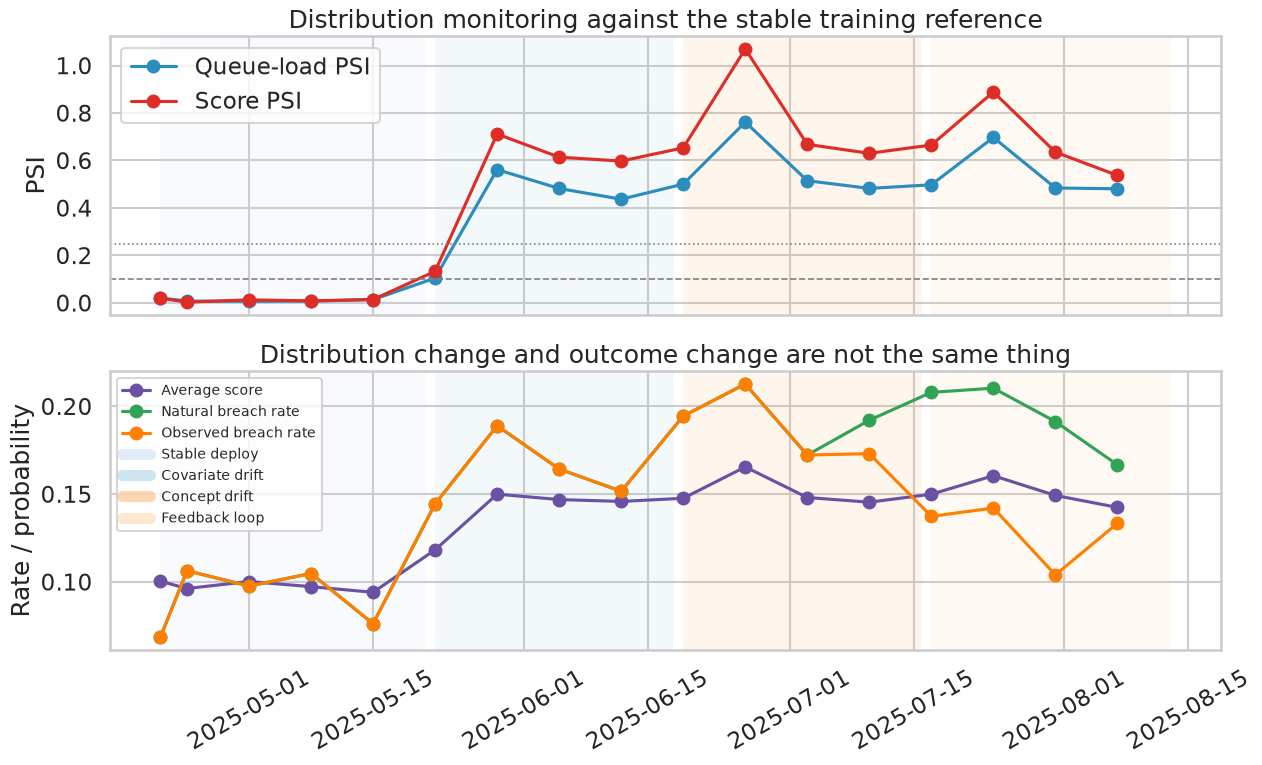

In [6]:
# Section focus: 4. Distribution Monitoring: Feature Drift and Score Drift.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def shade_phases(ax, df, alpha=0.12):
    """Carry out the shade phases step used in the 17. Monitoring Drift, Degradation, and Feedback Loops workflow.
    
    Parameters
    ----------
    ax : object
        Matplotlib axis on which the plot is drawn.
    df : object
        Input data frame containing the rows used in this notebook example.
    alpha : object
        Regularization, smoothing, or significance parameter used by the calculation.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    for phase in phase_order:
        phase_df = df.loc[df["phase"] == phase]
        if phase_df.empty:
            continue
        ax.axvspan(
            phase_df["week_start"].min(),
            phase_df["week_start"].max() + pd.Timedelta(days=6),
            color=phase_colors[phase],
            alpha=alpha,
            lw=0,
        )


fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(weekly_monitor["week_start"], weekly_monitor["queue_psi"], marker="o", color="#2b8cbe", label="Queue-load PSI")
axes[0].plot(weekly_monitor["week_start"], weekly_monitor["score_psi"], marker="o", color="#de2d26", label="Score PSI")
axes[0].axhline(0.10, ls="--", lw=1.2, color="gray")
axes[0].axhline(0.25, ls=":", lw=1.2, color="gray")
axes[0].set_title("Distribution monitoring against the stable training reference")
axes[0].set_ylabel("PSI")
axes[0].legend(loc="upper left")
shade_phases(axes[0], weekly_monitor)

axes[1].plot(weekly_monitor["week_start"], weekly_monitor["avg_score"], marker="o", color="#6a51a3", label="Average score")
axes[1].plot(weekly_monitor["week_start"], weekly_monitor["natural_breach_rate"], marker="o", color="#31a354", label="Natural breach rate")
axes[1].plot(weekly_monitor["week_start"], weekly_monitor["observed_breach_rate"], marker="o", color="#ff7f00", label="Observed breach rate")
axes[1].set_title("Distribution change and outcome change are not the same thing")
axes[1].set_ylabel("Rate / probability")
axes[1].legend(loc="upper left")
shade_phases(axes[1], weekly_monitor)

phase_handles = [
    Line2D([0], [0], color=phase_colors[p], lw=8, alpha=0.5, label=p) for p in phase_order if p != "Stable train"
]
axes[1].legend(handles=list(axes[1].get_legend().legend_handles) + phase_handles, loc="upper left", fontsize=10)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

These monitoring plots support three distinct conclusions.

1. **Stable deploy**: both PSI measures stay close to the training reference, and the outcome rates track the average score reasonably well.
2. **Covariate drift**: the PSI signals rise because the workload distribution has shifted. But visible feature drift needs to be connected to performance before it becomes a catastrophic warning.
3. **Concept drift**: the hidden outage process raises the natural breach rate more than the score anticipates, so calibration worsens even though the feature-drift dashboard alone does not fully explain why.

That distinction aligns with the concept-drift literature: monitoring feature movement and monitoring target behavior are complementary tasks, not interchangeable ones (Gama et al., 2014; Webb et al., 2016).

## 5. Outcome Monitoring: Calibration and Rank Quality Over Time

A production team usually wants to know two things at once:

- Are the scores still ranking cases well?
- Are the score levels still numerically trustworthy?

AUC summarizes ranking quality, while the calibration gap compares realized event rates to average predicted risk. They move for different reasons, so both should be tracked.

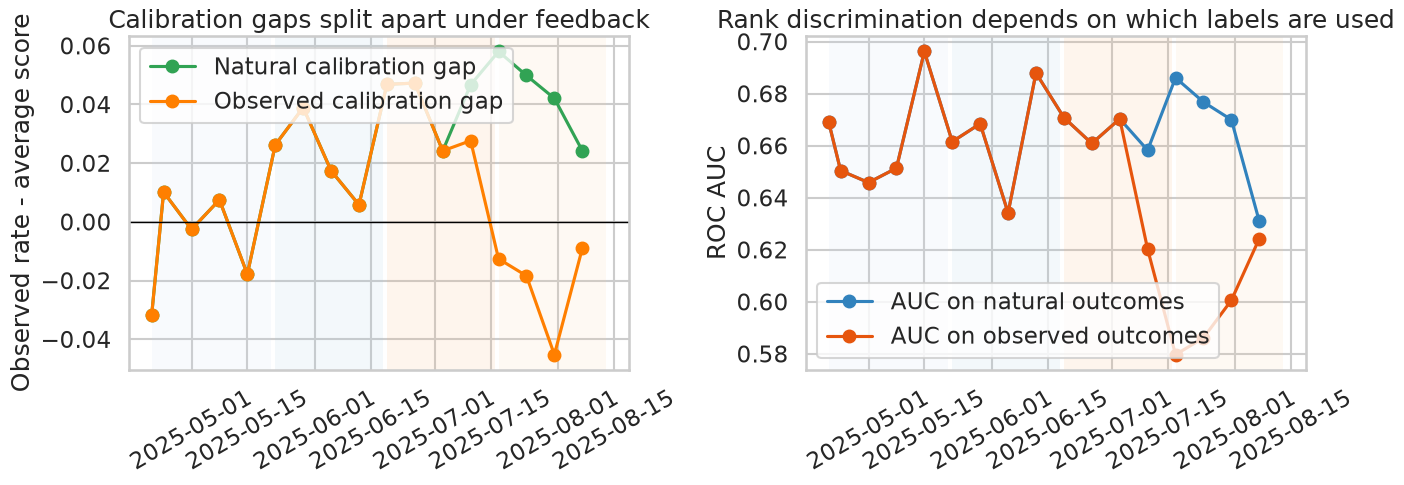

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True)

axes[0].plot(weekly_monitor["week_start"], weekly_monitor["natural_calibration_gap"], marker="o", color="#31a354", label="Natural calibration gap")
axes[0].plot(weekly_monitor["week_start"], weekly_monitor["observed_calibration_gap"], marker="o", color="#ff7f00", label="Observed calibration gap")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Calibration gaps split apart under feedback")
axes[0].set_ylabel("Observed rate - average score")
axes[0].legend(loc="upper left")
shade_phases(axes[0], weekly_monitor)

axes[1].plot(weekly_monitor["week_start"], weekly_monitor["auc_natural"], marker="o", color="#3182bd", label="AUC on natural outcomes")
axes[1].plot(weekly_monitor["week_start"], weekly_monitor["auc_observed"], marker="o", color="#e6550d", label="AUC on observed outcomes")
axes[1].set_title("Rank discrimination depends on which labels are used")
axes[1].set_ylabel("ROC AUC")
axes[1].legend(loc="lower left")
shade_phases(axes[1], weekly_monitor)

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

The feedback-loop phase is the critical one.

The natural calibration gap says the model is **underpredicting the untreated risk**. The observed calibration gap says the model is **overpredicting the realized post-intervention outcome**. Both are true, because they answer different questions.

This is why post-deployment monitoring can become philosophically confused if intervention logs are ignored. A model may appear "too pessimistic" against observed labels precisely because the deployed policy prevented some bad outcomes.

## 6. Threshold-Based Queue Monitoring

Many operational teams do not act on the full score distribution. They act on a queue, such as the top 20% of scores. So we should monitor the queue directly.

In this section, we compare queue-level metrics against:

- the **natural outcome**, which represents untreated risk in the simulation,
- the **observed outcome**, which reflects what actually happened after intervention.

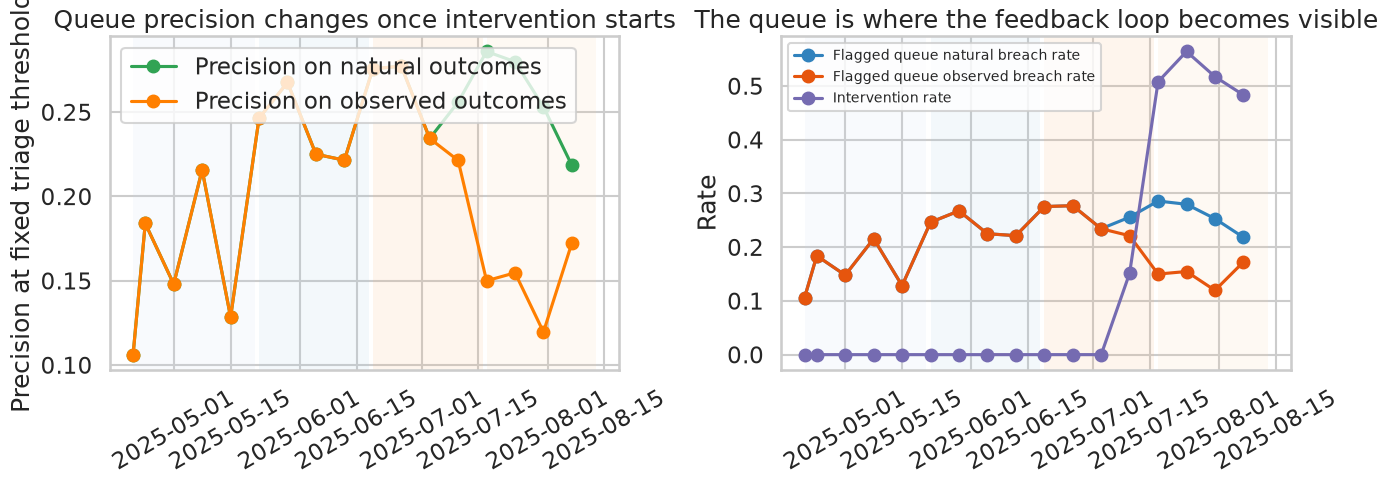

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True)

axes[0].plot(weekly_monitor["week_start"], weekly_monitor["precision_natural"], marker="o", color="#31a354", label="Precision on natural outcomes")
axes[0].plot(weekly_monitor["week_start"], weekly_monitor["precision_observed"], marker="o", color="#ff7f00", label="Precision on observed outcomes")
axes[0].set_title("Queue precision changes once intervention starts")
axes[0].set_ylabel("Precision at fixed triage threshold")
axes[0].legend(loc="upper left")
shade_phases(axes[0], weekly_monitor)

axes[1].plot(weekly_monitor["week_start"], weekly_monitor["flagged_natural_rate"], marker="o", color="#3182bd", label="Flagged queue natural breach rate")
axes[1].plot(weekly_monitor["week_start"], weekly_monitor["flagged_observed_rate"], marker="o", color="#e6550d", label="Flagged queue observed breach rate")
axes[1].plot(weekly_monitor["week_start"], weekly_monitor["intervention_rate"], marker="o", color="#756bb1", label="Intervention rate")
axes[1].set_title("The queue is where the feedback loop becomes visible")
axes[1].set_ylabel("Rate")
axes[1].legend(loc="upper left", fontsize=10)
shade_phases(axes[1], weekly_monitor)

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

This is the dashboard that many teams actually need.

During the feedback-loop phase, the observed breach rate inside the flagged queue falls because the intervention is helping. If we ignored that operational fact and retrained directly on these observed labels, we could mistakenly conclude that the high-score region is intrinsically less risky than it really is.

That logic is closely related to the general warning in the feedback-loop literature: when predictions drive resource allocation, the system can become self-referential unless monitoring preserves some connection to untreated or externally validated outcomes (Ensign et al., 2017).

## 7. A Compact Monitoring Table

A good production monitoring workflow should let a team answer three questions quickly:

1. Did the data distribution move?
2. Did the model-outcome relationship move?
3. Are the labels now being shaped by the policy itself?

The table below turns those questions into a compact phase-level summary.

In [9]:
phase_table = (
    weekly_monitor.groupby("phase")
    .agg(
        queue_psi=("queue_psi", "mean"),
        score_psi=("score_psi", "mean"),
        natural_gap=("natural_calibration_gap", "mean"),
        observed_gap=("observed_calibration_gap", "mean"),
        auc_natural=("auc_natural", "mean"),
        auc_observed=("auc_observed", "mean"),
        precision_natural=("precision_natural", "mean"),
        precision_observed=("precision_observed", "mean"),
        intervention_rate=("intervention_rate", "mean"),
    )
    .reindex(["Stable deploy", "Covariate drift", "Concept drift", "Feedback loop"])
    .reset_index()
)

display(phase_table)

,phase,queue_psi,score_psi,natural_gap,observed_gap,auc_natural,auc_observed,precision_natural,precision_observed,intervention_rate
0,Stable deploy,0.011101,0.011619,-0.006927,-0.006927,0.662591,0.662591,0.156483,0.156483,0.000000
1,Covariate drift,0.396191,0.513942,0.022085,0.022085,0.663014,0.663014,0.240122,0.240122,0.000000
2,Concept drift,0.564765,0.755269,0.041238,0.036476,0.665046,0.655534,0.260792,0.252158,0.037897
3,Feedback loop,0.539825,0.681492,0.043543,-0.021338,0.665940,0.597659,0.259321,0.149189,0.518254


A sensible reading of this table is:

- **Stable deploy**: this is the baseline operating regime.
- **Covariate drift**: PSI rises, but the model remains broadly usable.
- **Concept drift**: calibration on untreated risk worsens, so a pure feature-drift story is no longer enough.
- **Feedback loop**: observed queue metrics become policy-dependent, so naive monitoring and naive retraining both become dangerous.

## 8. Practical Checklist for Production Monitoring

A decision-science monitoring workflow should usually include the following:

1. **Keep an explicit reference window.** Monitoring needs a documented baseline, not a fuzzy memory of what once looked normal.
2. **Track feature drift and score drift separately.** They are related, but they are not the same object.
3. **Pair distribution alerts with outcome audits.** PSI can tell you that the world moved; it cannot tell you whether the model is still decision-worthy.
4. **Log interventions triggered by the model.** Without those logs, post-deployment labels are easy to misread.
5. **Monitor the action queue alongside the full population.** That is where operational consequences concentrate.
6. **Use holdouts, audits, or causal designs when actions change outcomes.** If the model changes the world, then evaluation becomes an identification problem.
7. **Retrain after diagnosis-driven review.** Automatic retraining on policy-contaminated labels can harden the wrong lesson.

The right reaction to a drift alert is diagnosis first. Inspect the mechanism and operational context, then decide whether the system needs recalibration, new features, randomized auditing, or retraining.

## References

- Brugman, S., Sostak, T., Patil, P., et al. (2022). *popmon: Analysis Package for Dataset Shift Detection.* [https://doi.org/10.25080/majora-212e5952-01d](https://doi.org/10.25080/majora-212e5952-01d)
- Ensign, D., Friedler, S. A., Neville, S., et al. (2017). *Runaway Feedback Loops in Predictive Policing.* [https://doi.org/10.48550/arXiv.1706.09847](https://doi.org/10.48550/arXiv.1706.09847)
- Gama, J., Žliobaitė, I., Bifet, A., et al. (2014). *A survey on concept drift adaptation.* *ACM Computing Surveys*, 46(4), 1-37. [https://doi.org/10.1145/2523813](https://doi.org/10.1145/2523813)
- Webb, G. I., Hyde, R., Cao, H., et al. (2016). *Characterizing concept drift.* *Data Mining and Knowledge Discovery*, 30(4), 964-994. [https://doi.org/10.1007/s10618-015-0448-4](https://doi.org/10.1007/s10618-015-0448-4)
